# Experiment 3: Regression Analysis using Linear and Regularized Models

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:

df = pd.read_csv("train.csv")


In [3]:

target_col = "Loan Sanction Amount (USD)"

X = df.drop(target_col, axis=1)
y = df[target_col]

X = X.drop(columns=["Customer ID", "Name", "Property ID"])


In [4]:

data = pd.concat([X, y], axis=1)
data = data.dropna(subset=[target_col])

X = data.drop(target_col, axis=1)
y = data[target_col]


In [5]:

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])


In [6]:

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])


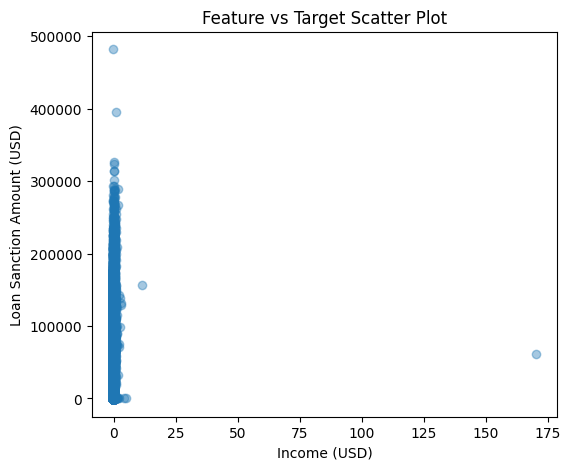

In [7]:

plt.figure(figsize=(6,5))
plt.scatter(X["Income (USD)"], y, alpha=0.4)
plt.xlabel("Income (USD)")
plt.ylabel("Loan Sanction Amount (USD)")
plt.title("Feature vs Target Scatter Plot")
plt.show()


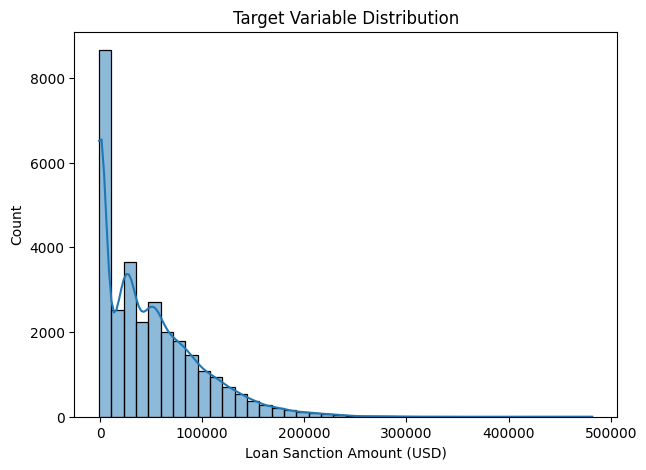

In [8]:

plt.figure(figsize=(7,5))
sns.histplot(y, bins=40, kde=True)
plt.title("Target Variable Distribution")
plt.xlabel("Loan Sanction Amount (USD)")
plt.ylabel("Count")
plt.show()


In [9]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:

start = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_time = time.time() - start

y_pred_lr = lr.predict(X_test)


In [69]:
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_lr)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_lr)}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred_lr))}")
print(f"R2 Score: {r2_score(y_test, y_pred_lr)}")


Mean Squared Error: 1014696940.1291991
Mean Absolute Error: 21553.08412812824
Root Mean Squared Error: 31854.308030927295
R2 Score: 0.5529525442339105


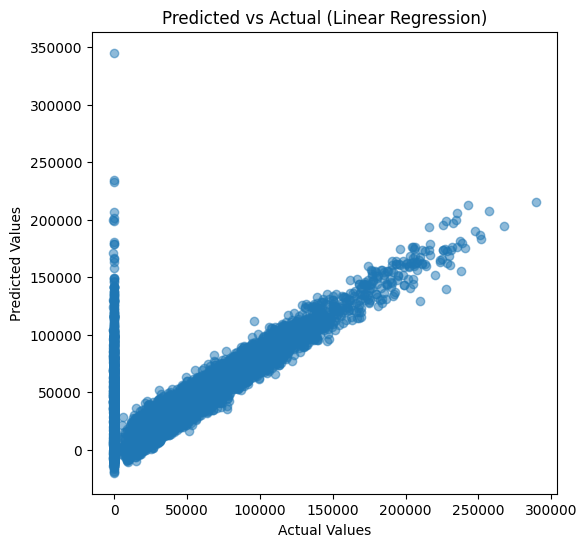

In [11]:

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual (Linear Regression)")
plt.show()


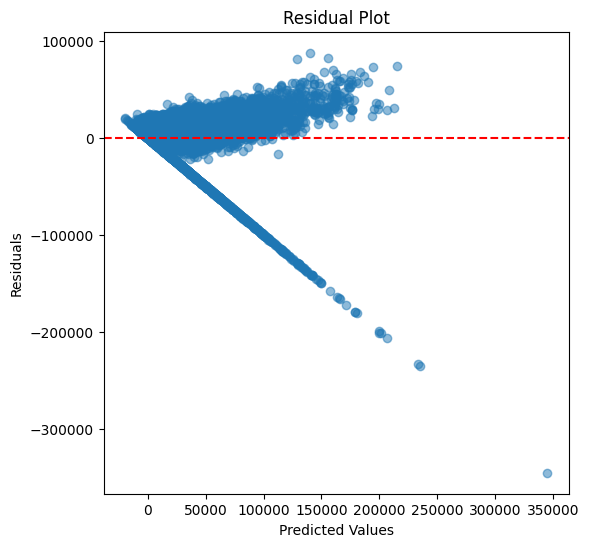

In [12]:

residuals = y_test - y_pred_lr

plt.figure(figsize=(6,6))
plt.scatter(y_pred_lr, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


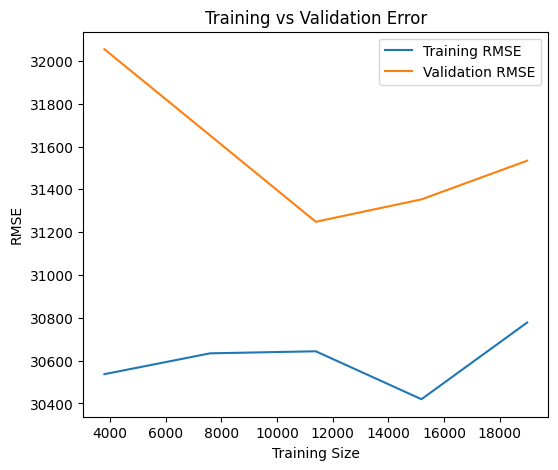

In [13]:

train_sizes, train_scores, val_scores = learning_curve(
    lr, X_train, y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=1
)

plt.figure(figsize=(6,5))
plt.plot(train_sizes, np.sqrt(-train_scores.mean(axis=1)), label="Training RMSE")
plt.plot(train_sizes, np.sqrt(-val_scores.mean(axis=1)), label="Validation RMSE")
plt.xlabel("Training Size")
plt.ylabel("RMSE")
plt.title("Training vs Validation Error")
plt.legend()
plt.show()


In [15]:

rd = Ridge()
rd.fit(X_train,y_train)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
y_pred = rd.predict(X_test)  
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")


Mean Squared Error: 1014571217.6553123
Mean Absolute Error: 21548.939516528913
Root Mean Squared Error: 31852.334571508447
R2 Score: 0.5530079340846737


In [19]:
la = Lasso()
la.fit(X_train,y_train)

C:\Users\Sabarithan P\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.364e+12, tolerance: 5.550e+09
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [22]:
y_pred = la.predict(X_test)
print(f"Mean Squared Error: {mean_squared_error(y_test,y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test,y_pred)}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"R2 Score: {r2_score(y_test,y_pred)}")

Mean Squared Error: 1014497312.8727211
Mean Absolute Error: 21539.996075091032
Root Mean Squared Error: 31851.17443474763
R2 Score: 0.5530404944913525


In [23]:
elasticnetmodel = ElasticNet(max_iter=10000)
elasticnetmodel.fit(X_train,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [24]:
y_pred = elasticnetmodel.predict(X_test)

In [26]:
print(f"Mean Squared Error: {mean_squared_error(y_test,y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test,y_pred)}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"R2 Score: {r2_score(y_test,y_pred)}")

Mean Squared Error: 1067571311.7082238
Mean Absolute Error: 23061.27392352425
Root Mean Squared Error: 32673.70979408711
R2 Score: 0.5296575559917815


In [29]:
para_grid = {
    'alpha': [0.1,0.2,0.4,0.6,0.8]
}

ridgegd = GridSearchCV(Ridge(),para_grid, cv = 5,scoring='r2', n_jobs = -1)

In [30]:
start_time = time.time()
ridgegd.fit(X_train,y_train)
end_time = time.time()

In [31]:
ridge_training_time = end_time - start_time
y_pred = ridgegd.predict(X_test)

In [35]:
print("Ridge Regression - Hyperparameter Tuning Results\n")
print("Best Parameters:", ridgegd.best_params_)
print("Best CV R²      :", ridgegd.best_score_)
print("\nValidation Metrics:")
print(f"MAE : {mean_absolute_error(y_test,y_pred):.2f}")
print(f"MSE : {mean_squared_error(y_test,y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²  : {r2_score(y_test,y_pred):.4f}")
print("\nTraining Time (s):", ridge_training_time)

Ridge Regression - Hyperparameter Tuning Results

Best Parameters: {'alpha': 0.8}
Best CV R²      : 0.5750269859598134

Validation Metrics:
MAE : 21549.54
MSE : 1014587873.35
RMSE: 31852.60
R²  : 0.5530

Training Time (s): 6.4071080684661865


In [36]:
para_grid = {
    'alpha': [0.01,0.1,1,10,100]
}

gdl = GridSearchCV(Lasso(),para_grid,cv=5,scoring='r2', n_jobs = -1)

In [37]:
start_time = time.time()
gdl.fit(X_train,y_train)
end_time = time.time()

In [38]:
lasso_training_time  = end_time - start_time
y_pred = gdl.predict(X_test)

In [40]:
print("Best Parameters:", gdl.best_params_)
print("Best CV R²      :", gdl.best_score_)
print("\nValidation Metrics:")
print(f"MAE : {mean_absolute_error(y_test,y_pred):.2f}")
print(f"MSE : {mean_squared_error(y_test,y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²  : {r2_score(y_test,y_pred):.4f}")
print("\nTraining Time (s):", lasso_training_time)

Best Parameters: {'alpha': 100}
Best CV R²      : 0.591607911444919

Validation Metrics:
MAE : 21539.30
MSE : 1013207748.85
RMSE: 31830.92
R²  : 0.5536

Training Time (s): 1.8122570514678955


In [41]:
para_grid = {
    'alpha' : [0.01,0.1,1,10],
    'l1_ratio' : [0.2,0.5,0.8]
}

elasticgrid = GridSearchCV(ElasticNet(),para_grid,cv = 5,scoring='r2',n_jobs = -1)

In [44]:
start_time = time.time()
elasticgrid.fit(X_train,y_train)
end_time = time.time()

In [45]:
elastic_training_time = end_time - start_time
y_pred = elasticgrid.predict(X_test)

In [46]:
print("Best Parameters:", elasticgrid.best_params_)
print("Best CV R²      :", elasticgrid.best_score_)
print("\nValidation Metrics:")
print(f"MAE : {mean_absolute_error(y_test,y_pred):.2f}")
print(f"MSE : {mean_squared_error(y_test,y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²  : {r2_score(y_test,y_pred):.4f}")
print("\nTraining Time (s):", elastic_training_time)

Best Parameters: {'alpha': 0.1, 'l1_ratio': 0.5}
Best CV R²      : 0.5855085841638777

Validation Metrics:
MAE : 21730.79
MSE : 1015622194.26
RMSE: 31868.83
R²  : 0.5525

Training Time (s): 3.0565929412841797


In [54]:
best_ridge = ridgegd.best_estimator_
best_lasso = gdl.best_estimator_
best_elastic = elasticgrid.best_estimator_

cv_table = pd.DataFrame({
    "Linear": cross_val_score(lr, X, y, cv=5, scoring="r2").mean(),
    "Ridge": cross_val_score(best_ridge, X, y, cv=5, scoring="r2").mean(),
    "Lasso": cross_val_score(best_lasso, X, y, cv=5, scoring="r2").mean(),
    "ElasticNet": cross_val_score(best_elastic, X, y, cv=5, scoring="r2").mean()
}, index=["CV R2"])

cv_table


,Linear,Ridge,Lasso,ElasticNet
CV R2,0.576085,0.576207,0.585428,0.580169


In [64]:
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return [
        round(mean_absolute_error(y_true, y_pred), 2),
        round(mse, 2),
        round(np.sqrt(mse), 2),
        round(r2_score(y_true, y_pred), 4)
    ]


In [65]:
# Linear Regression
y_pred_lr = lr.predict(X_test)

# Ridge (best tuned model)
best_ridge = ridgegd.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

# Lasso
best_lasso = gdl.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

# ElasticNet
best_elastic = elasticgrid.best_estimator_
y_pred_elastic = best_elastic.predict(X_test)


In [66]:
test_table = pd.DataFrame(
    [
        metrics(y_test, y_pred_lr),
        metrics(y_test, y_pred_ridge),
        metrics(y_test, y_pred_lasso),
        metrics(y_test, y_pred_elastic)
    ],
    columns=["MAE", "MSE", "RMSE", "R2"],
    index=["Linear", "Ridge", "Lasso", "ElasticNet"]
)

test_table


,MAE,MSE,RMSE,R2
Linear,21553.08,1.014697e+09,31854.31,0.5530
Ridge,21549.54,1.014588e+09,31852.60,0.5530
Lasso,21539.30,1.013208e+09,31830.92,0.5536
ElasticNet,21730.79,1.015622e+09,31868.83,0.5525


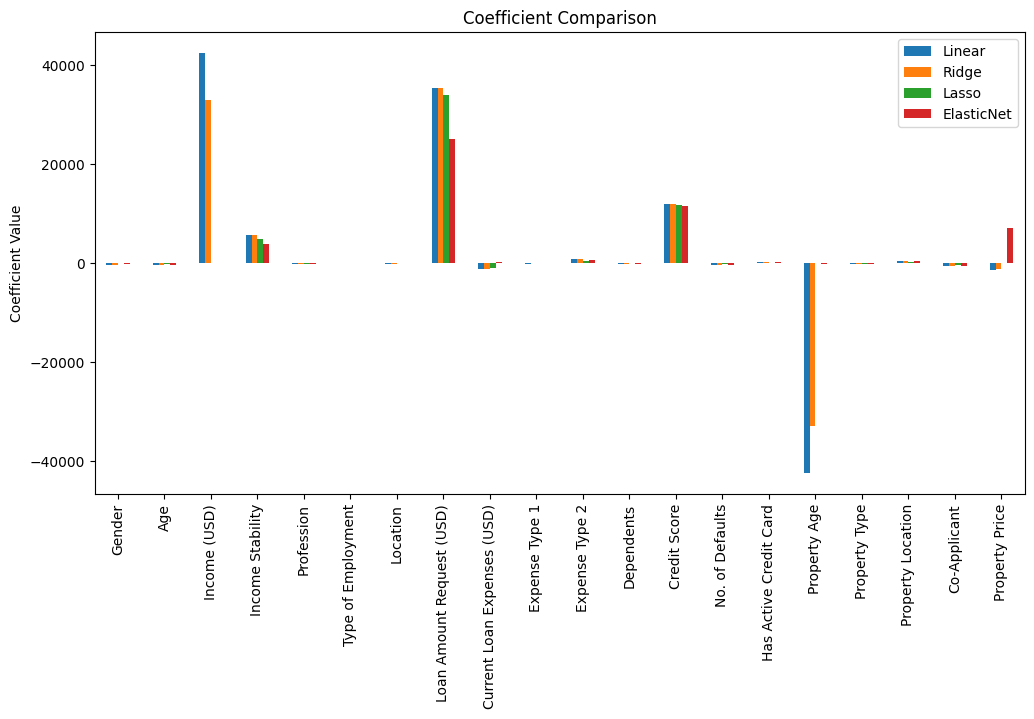

In [67]:

coef_df = pd.DataFrame({
    "Linear": lr.coef_,
    "Ridge": best_ridge.coef_,
    "Lasso": best_lasso.coef_,
    "ElasticNet": best_elastic.coef_
}, index=X.columns)

coef_df.plot(kind="bar", figsize=(12,6))
plt.title("Coefficient Comparison")
plt.ylabel("Coefficient Value")
plt.show()
